<a href="https://colab.research.google.com/github/SoniaElizabeth/ICT_DSA_2026/blob/main/Unsupervised_Learning_Casestudy_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

##Encoding
from sklearn.preprocessing import LabelEncoder,OneHotEncoder


# Loading dataset

In [7]:
file_path = '/content/adult_dataset.csv'

In [8]:
policy_df = pd.read_csv(file_path)
policy_df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [9]:
policy_df.shape

(48842, 15)

In [10]:
policy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [11]:
policy_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


# Data preprocessing and EDA

### Duplicate value Handling

In [12]:
policy_df.duplicated().sum()

np.int64(16)

In [13]:
policy_df.drop_duplicates(inplace=True)

### splitting Num and Cat Values

In [14]:
policy_df_num_cols= policy_df.select_dtypes(include=['int64','float64']).columns
policy_df_cat_cols= policy_df.select_dtypes(include=['object']).columns

In [15]:
policy_df_num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [16]:
policy_df_cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

### Missing value handling

In [17]:
policy_df.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [18]:
missing_percent_policy=policy_df.isna().sum()/len(policy_df)*100  ## Checking the  % of missing values
sorted=missing_percent_policy.sort_values(ascending=True)

In [19]:
sorted ##Missing value value percent

,0
education,0.000000
fnlwgt,0.000000
marital-status,0.000000
education-num,0.000000
relationship,0.000000
capital-gain,0.000000
sex,0.000000
race,0.000000
income,0.000000
capital-loss,0.000000


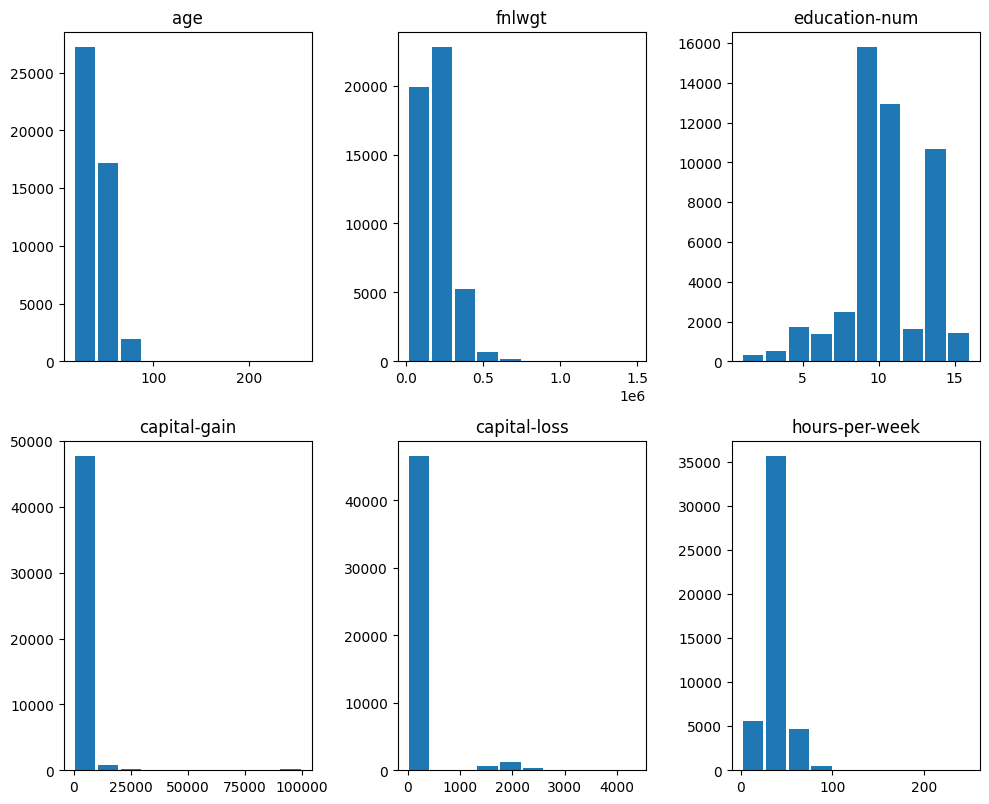

In [20]:
##Plot to understand numerical value distribution in training data

plt.figure(figsize=(10,12))
for i, col in enumerate(policy_df_num_cols,1):
  plt.subplot(3,3,i)
  plt.hist(policy_df[col],rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [21]:
policy_df['age']=policy_df['age'].fillna(policy_df['age'].median())
policy_df['hours-per-week']=policy_df['hours-per-week'].fillna(policy_df['hours-per-week'].median())

##replacing null values with median in num_cols



In [22]:
policy_df.isna().sum()

,0
age,0
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [23]:
policy_df['workclass'].value_counts()

,count
workclass,
Private,32205
Self-emp-not-inc,3649
Local-gov,2973
State-gov,1877
?,1763
Self-emp-inc,1624
Federal-gov,1346
Without-pay,18
Never-worked,9


In [24]:
for col in policy_df_cat_cols:
  print({col})
  print(policy_df[col].value_counts())

{'workclass'}
workclass
Private             32205
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
?                    1763
Self-emp-inc         1624
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64
{'education'}
education
HS-grad         15780
Some-college    10874
Bachelors        8021
Masters          2657
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              656
Doctorate         594
5th-6th           508
1st-4th           246
Preschool          83
Name: count, dtype: int64
{'marital-status'}
marital-status
Married-civ-spouse       22377
Never-married            16105
Divorced                  6631
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64
{'occupation'}
occupation
Prof-specia

In [25]:
policy_df['occupation'].value_counts()

,count
occupation,
Prof-specialty,5851
Craft-repair,5790
Exec-managerial,5770
Adm-clerical,5328
Sales,5231
Other-service,4654
Machine-op-inspct,2872
Transport-moving,2238
Handlers-cleaners,1976


In [26]:
policy_df['native-country'].value_counts()

,count
native-country,
United-States,41609
Mexico,906
?,555
Philippines,282
Germany,194
Puerto-Rico,175
Canada,170
El-Salvador,147
India,143


In [27]:
# null Values in numerical cols are removed.
# handling null values in categorical columns
# Using mode to replace null values

In [28]:
##Replacing cat_col null values with mode
policy_df['workclass']=policy_df['workclass'].fillna(policy_df['workclass'].mode()[0])
policy_df['occupation']=policy_df['occupation'].fillna(policy_df['occupation'].mode()[0])
policy_df['native-country']=policy_df['native-country'].fillna(policy_df['native-country'].mode()[0])

In [29]:
policy_df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [30]:
import numpy as np

for col in policy_df_cat_cols:
    policy_df[col] = policy_df[col].replace('?', np.nan) ##Replacing '?'  valuw with NaN

In [31]:
policy_df.isna().sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [32]:
policy_df['workclass']= policy_df['workclass'].fillna(policy_df['workclass'].mode()[0])
policy_df['occupation']= policy_df['occupation'].fillna(policy_df['occupation'].mode()[0])
policy_df['native-country']= policy_df['native-country'].fillna(policy_df['native-country'].mode()[0]) ##Replacing Nan with mode



In [33]:
policy_df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [34]:
for col in policy_df_cat_cols:
  print(policy_df[col].value_counts())  ##Cheching whether the '?' removed or not

workclass
Private             37330
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
Self-emp-inc         1624
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64
education
HS-grad         15780
Some-college    10874
Bachelors        8021
Masters          2657
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              656
Doctorate         594
5th-6th           508
1st-4th           246
Preschool          83
Name: count, dtype: int64
marital-status
Married-civ-spouse       22377
Never-married            16105
Divorced                  6631
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64
occupation
Prof-specialty       10966
Craft-repair          5790
Exec-managerial       5770
Adm-clerical      

###Outlier Handling

In [35]:
##Before outlier handling

policy_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48826.000000,4.882600e+04,48826.000000,48826.000000,48826.000000,48826.000000
mean,38.597428,1.896605e+05,10.078278,1079.421230,87.530988,40.428481
std,13.602653,1.056025e+05,2.570759,7453.214369,403.067466,12.326046
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376170e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


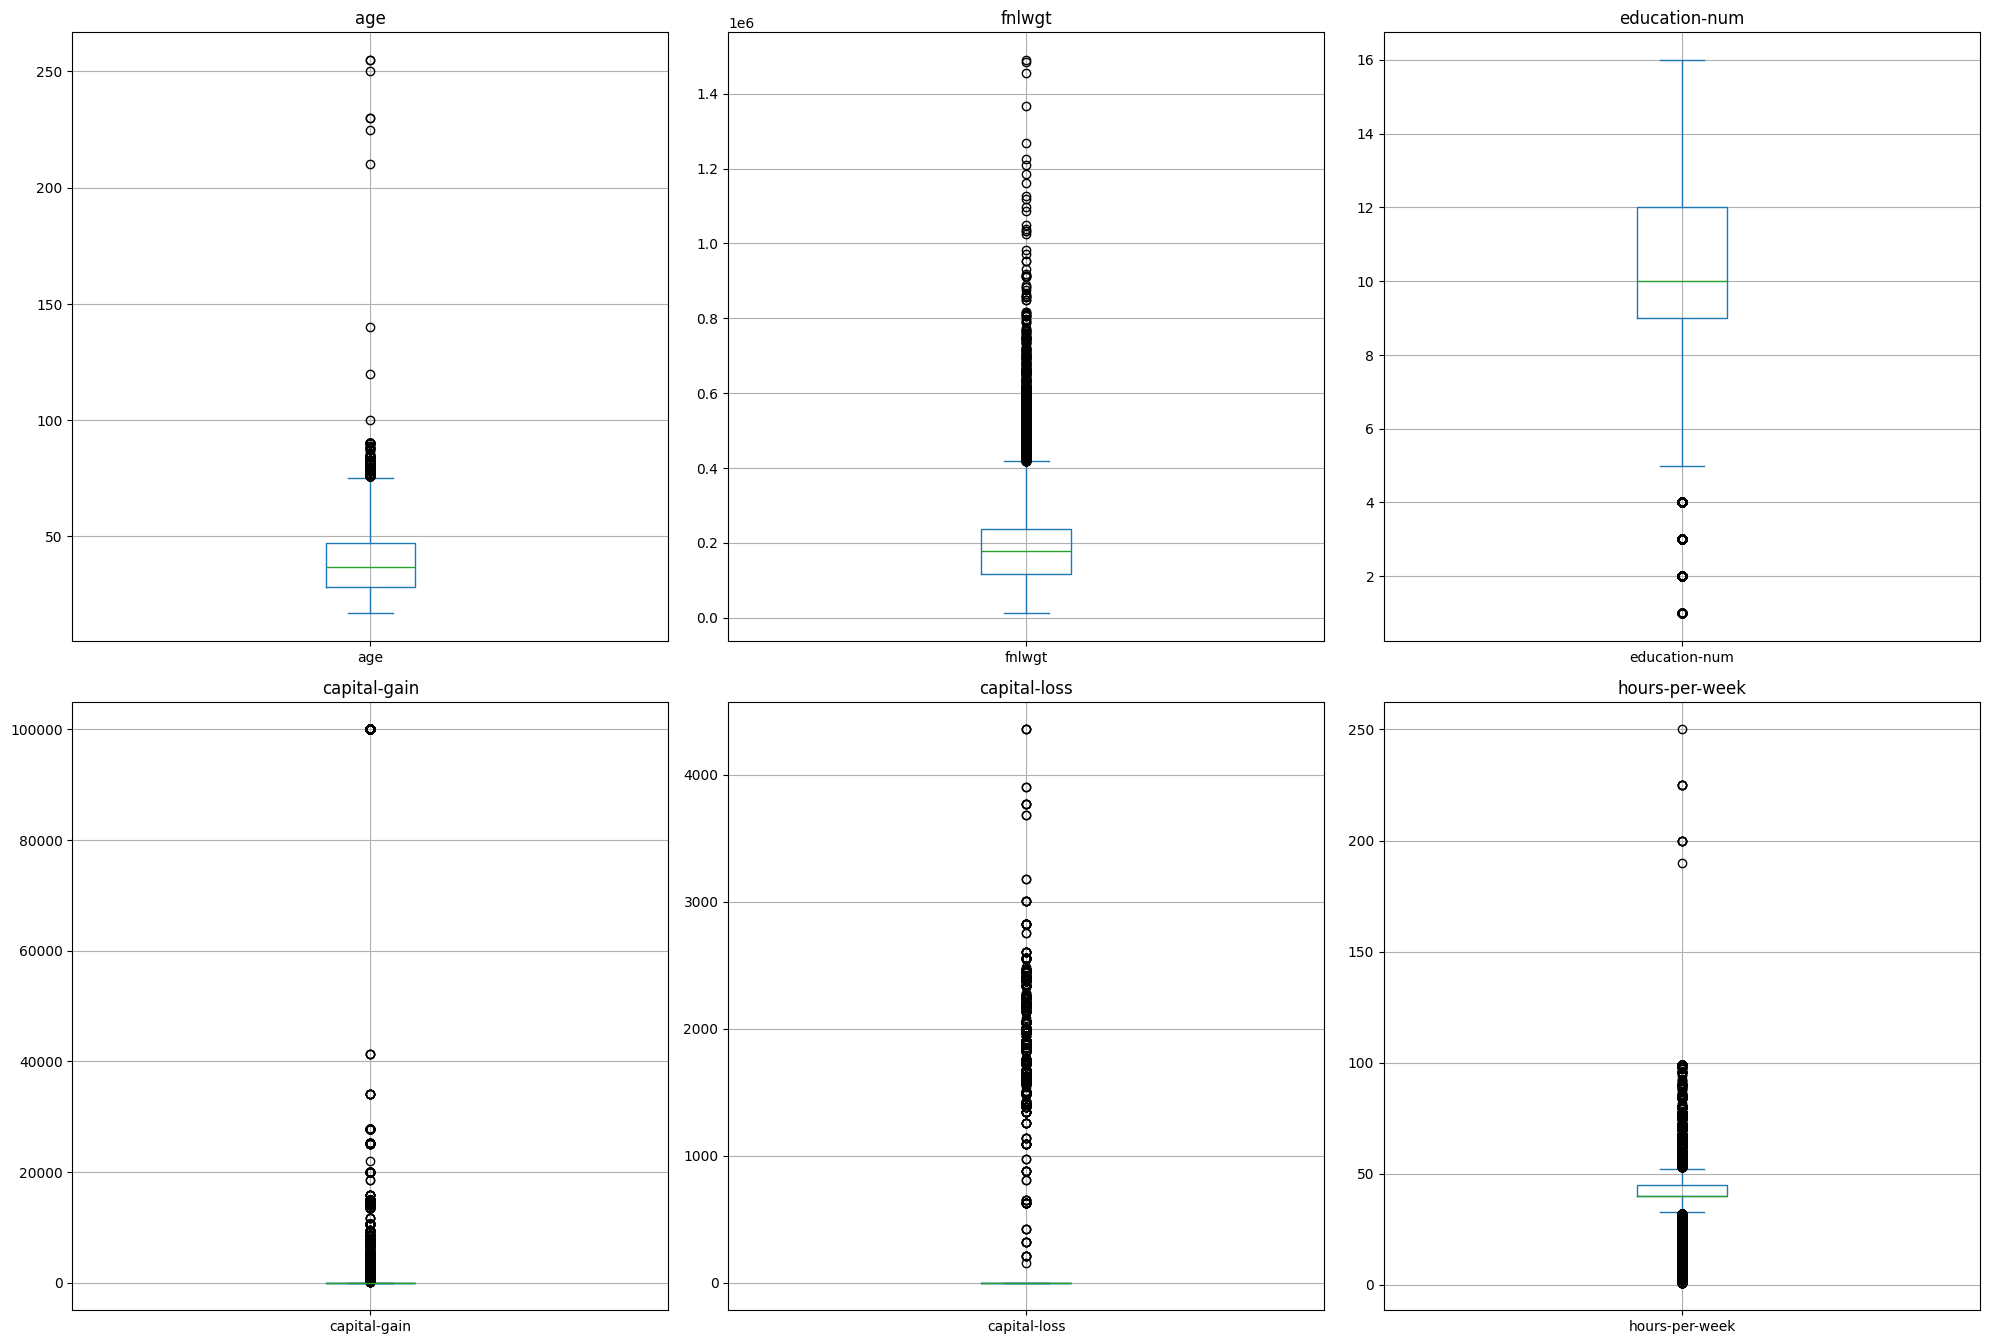

In [36]:
# ploting box plot to identify outlier

plt.figure(figsize=(20,20))
for i, col in enumerate (policy_df_num_cols, 1):
  plt.subplot(3,3,i)
  policy_df[col].plot(kind='box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [37]:
Q1 = policy_df[policy_df_num_cols].quantile(0.25)
Q3 = policy_df[policy_df_num_cols].quantile(0.75)
IQR = Q3-Q1


upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((policy_df[policy_df_num_cols] > upper_limit) | (policy_df[policy_df_num_cols] < lower_limit)).any(axis=1)

outliers_df = policy_df[outliers]

outlier_percentage = len(outliers_df) * 100/ len(policy_df)

print("percentage fo outliers in the dataframe :", outlier_percentage)


percentage fo outliers in the dataframe : 40.447712284438616


In [38]:
outliers_count = ((policy_df[policy_df_num_cols] > upper_limit) | (policy_df[policy_df_num_cols] < lower_limit)).mean()*100

In [39]:
outliers_count

,0
age,0.743456
fnlwgt,2.975874
education-num,3.670176
capital-gain,8.264040
capital-loss,4.673739
hours-per-week,26.283128


In [40]:
# List of columns to exclude from IQR capping
exclude_cols = ['capital-gain', 'capital-loss','hours-per-week']

# Create a new list for columns that SHOULD be capped
cols_to_cap = [col for col in policy_df_num_cols if col not in exclude_cols]

# Capping only the relevant columns
for col in cols_to_cap:
    policy_df[col] = np.where(policy_df[col] > upper_limit[col], upper_limit[col],
                     np.where(policy_df[col] < lower_limit[col], lower_limit[col], policy_df[col]))



In [41]:
# Since 250 workhour a week is not possible, capping values where it exceeds '100'


policy_df['hours-per-week']= np.where(policy_df['hours-per-week'] > 100, np.nan, policy_df['hours-per-week'])



In [42]:
# Not ideal to cap these because the difference between a $50,000 gain and a $99,000 gain actually matters for clustering rich people.
# Log transform instead of capping to keep the data variance
policy_df['capital-gain'] = np.log1p(policy_df['capital-gain'])
policy_df['capital-loss'] = np.log1p(policy_df['capital-loss'])


In [43]:
policy_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48816.000000
mean,38.533927,186764.026687,10.122209,0.728783,0.351088,40.392924
std,13.270067,95318.219533,2.456853,2.445845,1.586480,12.071672
min,17.000000,12285.000000,4.500000,0.000000,0.000000,1.000000
25%,28.000000,117555.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,178138.500000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,237617.000000,12.000000,0.000000,0.000000,45.000000
max,75.500000,417710.000000,16.000000,11.512925,8.379539,99.000000


##Identifying Coorelation  (EDA)

In [44]:
## Coorelation matrix
corr_matrix = policy_df[policy_df_num_cols].corr(method='pearson')
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076939,0.041684,0.121239,0.051819,0.069823
fnlwgt,-0.076939,1.000000,-0.034830,-0.007159,-0.001766,-0.011855
education-num,0.041684,-0.034830,1.000000,0.132567,0.080456,0.143292
capital-gain,0.121239,-0.007159,0.132567,1.000000,-0.065942,0.083579
capital-loss,0.051819,-0.001766,0.080456,-0.065942,1.000000,0.048339
hours-per-week,0.069823,-0.011855,0.143292,0.083579,0.048339,1.000000


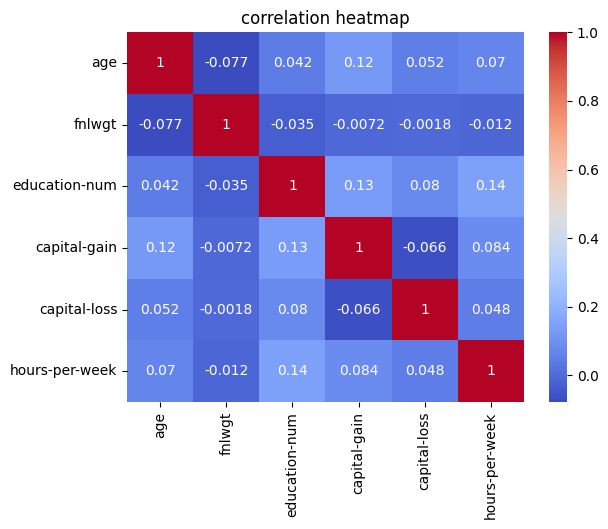

In [45]:
sns.heatmap(corr_matrix, cmap='coolwarm',annot=True)
plt.title('correlation heatmap')
plt.show()

In [46]:
# Dropping fnlwgt as it is a census weighting factor and not a personal characteristic
policy_df.drop('fnlwgt', axis=1, inplace=True)

# Update your numerical columns list as well
policy_df_num_cols = policy_df_num_cols.drop('fnlwgt')


In [47]:
policy_df.head(2) ##df alfter removing fnlwgt columns

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13.0,United-States,<=50K


###Scalinng

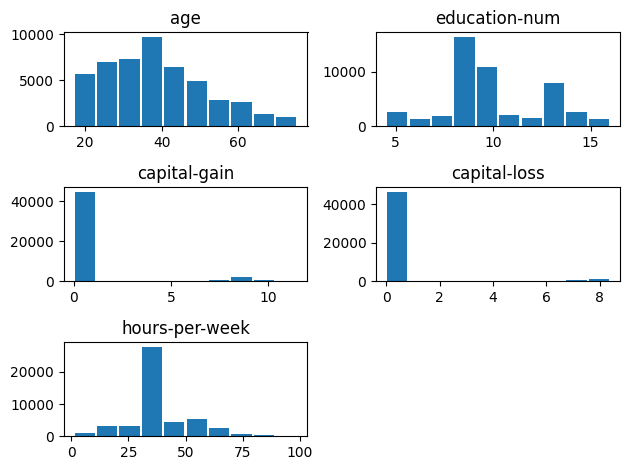

In [48]:
for i, col in enumerate(policy_df_num_cols,1):
  plt.subplot(3,2,i)
  plt.hist(policy_df[col],rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [49]:
##Before scaling

policy_df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48826.000000,48826.000000,48826.000000,48826.000000,48816.000000
mean,38.533927,10.122209,0.728783,0.351088,40.392924
std,13.270067,2.456853,2.445845,1.586480,12.071672
min,17.000000,4.500000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,12.000000,0.000000,0.000000,45.000000
max,75.500000,16.000000,11.512925,8.379539,99.000000


In [50]:
scaler= StandardScaler()

##Initailize the scaler
policy_df[policy_df_num_cols] = scaler.fit_transform(policy_df[policy_df_num_cols])

In [51]:
##After scaling

policy_df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,4.882600e+04,4.882600e+04,4.882600e+04,4.882600e+04,4.881600e+04
mean,1.018678e-17,2.552517e-16,1.688096e-17,8.047559e-17,3.493327e-18
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.622761e+00,-2.288402e+00,-2.979709e-01,-2.213022e-01,-3.263287e+00
25%,-7.938192e-01,-4.567718e-01,-2.979709e-01,-2.213022e-01,-3.254963e-02
50%,-1.155942e-01,-4.974280e-02,-2.979709e-01,-2.213022e-01,-3.254963e-02
75%,6.379893e-01,7.643152e-01,-2.979709e-01,-2.213022e-01,3.816475e-01
max,2.785702e+00,2.392431e+00,4.409214e+00,5.060597e+00,4.854976e+00


In [52]:
# corelation after scaling
corr_matrix = policy_df[policy_df_num_cols].corr(method='pearson')
corr_matrix

,age,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,0.041684,0.121239,0.051819,0.069823
education-num,0.041684,1.000000,0.132567,0.080456,0.143292
capital-gain,0.121239,0.132567,1.000000,-0.065942,0.083579
capital-loss,0.051819,0.080456,-0.065942,1.000000,0.048339
hours-per-week,0.069823,0.143292,0.083579,0.048339,1.000000


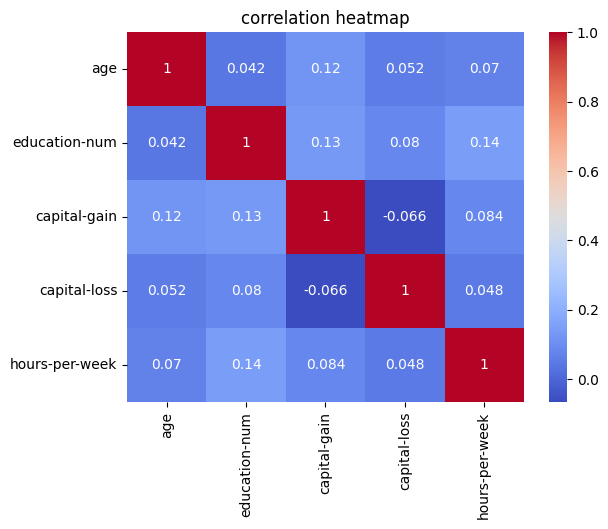

In [53]:
## ploting a heat map to visualize correlation after scaling
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [54]:
##Before encoding

policy_df.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.035123,State-gov,Bachelors,1.171344,Never-married,Adm-clerical,Not-in-family,White,Male,2.844037,-0.221302,-0.032550,United-States,<=50K
1,0.864064,Self-emp-not-inc,Bachelors,1.171344,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.297971,-0.221302,-2.269214,United-States,<=50K
2,-0.040236,Private,HS-grad,-0.456772,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.297971,-0.221302,-0.032550,United-States,<=50K


In [55]:
# Iterating through categorical columns to see unique values and counts
for col in policy_df_cat_cols:
    print(policy_df[col].value_counts())

workclass
Private             37330
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
Self-emp-inc         1624
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64
education
HS-grad         15780
Some-college    10874
Bachelors        8021
Masters          2657
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              656
Doctorate         594
5th-6th           508
1st-4th           246
Preschool          83
Name: count, dtype: int64
marital-status
Married-civ-spouse       22377
Never-married            16105
Divorced                  6631
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64
occupation
Prof-specialty       10966
Craft-repair          5790
Exec-managerial       5770
Adm-clerical      

### Grouping values inside cat_cols

In [56]:
##### Grouping of Appropriate Values before encoding because many columns has numorous values ,
#### when we do one-hot encoding the no of columns will increase dimentionality


# Group Native-Country
policy_df['native-country'] = policy_df['native-country'].apply(lambda x: 'United-States' if x == 'United-States' else 'Other')

# Group Education
school_levels = ['11th', '9th', '7th-8th', '5th-6th', '10th', '1st-4th', 'Preschool', '12th']
policy_df['education'] = policy_df['education'].replace(school_levels, 'School')



In [57]:
policy_df['education'].value_counts()

,count
education,
HS-grad,15780
Some-college,10874
Bachelors,8021
School,6405
Masters,2657
Assoc-voc,2060
Assoc-acdm,1601
Prof-school,834
Doctorate,594


In [58]:
policy_df['native-country'].value_counts()

,count
native-country,
United-States,44869
Other,3957


In [59]:
#  Strip whitespace to ensure matches work correctly
policy_df['marital-status'] = policy_df['marital-status'].str.strip()

# Define the committed group
committed_levels = ['Married-civ-spouse', 'Married-AF-spouse']

#Update the existing column
policy_df['marital-status'] = policy_df['marital-status'].apply(
    lambda x: 'committed' if x in committed_levels else 'single'
)


In [60]:
policy_df['marital-status'].value_counts()

,count
marital-status,
single,26412
committed,22414


In [61]:
# Clean the column first to remove leading/trailing spaces
policy_df['occupation'] = policy_df['occupation'].str.strip()

# Map into broader categories based on job characteristics
occ_mapping = {
    # White Collar / Professional
    'Prof-specialty': 'Professional',
    'Exec-managerial': 'Professional',
    'Adm-clerical': 'White-Collar',
    'Sales': 'White-Collar',
    'Tech-support': 'White-Collar',

    # Blue Collar / Technical
    'Craft-repair': 'Blue-Collar',
    'Machine-op-inspct': 'Blue-Collar',
    'Transport-moving': 'Blue-Collar',
    'Handlers-cleaners': 'Blue-Collar',
    'Farming-fishing': 'Blue-Collar',

    # Service / Other
    'Other-service': 'Service',
    'Priv-house-serv': 'Service',
    'Protective-serv': 'Service',
    'Armed-Forces': 'Service' # Combined because it's only 15 rows
}

# Apply the update
policy_df['occupation'] = policy_df['occupation'].map(occ_mapping)




In [62]:
policy_df['occupation'].value_counts()


,count
occupation,
Professional,16736
Blue-Collar,14304
White-Collar,11941
Service,5845


In [63]:
# Display unique values for categorical columns only
for col in policy_df_cat_cols:
    if col in policy_df.columns:
        print(f"({policy_df[col].nunique()}): {policy_df[col].unique()}")


(8): ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
(9): ['Bachelors' 'HS-grad' 'School' 'Masters' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' 'Doctorate' 'Prof-school']
(2): ['single' 'committed']
(4): ['White-Collar' 'Professional' 'Blue-Collar' 'Service']
(6): ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
(5): ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
(2): ['Male' 'Female']
(2): ['United-States' 'Other']
(4): ['<=50K' '>50K' '<=50K.' '>50K.']


### Encodinng

In [64]:
Lencoder= LabelEncoder() ## Label encoding for ordinal data

label_cols = ['sex', 'marital-status', 'native-country']

for col in label_cols:
    policy_df[col] = Lencoder.fit_transform(policy_df[col])

In [65]:
# Drop the text education column (we use education-num instead)
if 'education' in policy_df.columns:
    policy_df.drop('education', axis=1, inplace=True)

In [66]:
#One-Hot Encode the remaining multi-category columns

cols_to_ohe = ['workclass', 'occupation', 'relationship', 'race', ]
policy_df = pd.get_dummies(policy_df, columns=cols_to_ohe, drop_first=True, dtype=int)

In [67]:
# Set pandas to show every column in the table
## after encoding
pd.set_option('display.max_columns', None)

policy_df.head()

,age,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_Professional,occupation_Service,occupation_White-Collar,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,0.035123,1.171344,1,1,2.844037,-0.221302,-0.032550,1,<=50K,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
1,0.864064,1.171344,0,1,-0.297971,-0.221302,-2.269214,1,<=50K,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1
2,-0.040236,-0.456772,1,1,-0.297971,-0.221302,-0.032550,1,<=50K,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
3,1.090139,-1.270830,0,1,-0.297971,-0.221302,-0.032550,1,<=50K,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,-0.793819,1.171344,0,0,-0.297971,-0.221302,-0.032550,0,<=50K,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0


In [68]:
policy_df= policy_df.drop('income',axis=1) ##Drop income columns because we are not using income as targeted column

In [69]:

policy_df.head(2)

,age,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_Professional,occupation_Service,occupation_White-Collar,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,0.035123,1.171344,1,1,2.844037,-0.221302,-0.032550,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
1,0.864064,1.171344,0,1,-0.297971,-0.221302,-2.269214,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1


In [70]:
policy_df.dropna(inplace=True)

In [71]:
policy_df.isna().sum()

,0
age,0
education-num,0
marital-status,0
sex,0
capital-gain,0
capital-loss,0
hours-per-week,0
native-country,0
workclass_Local-gov,0
workclass_Never-worked,0


##Clustering

In [72]:
X = policy_df

In [73]:
## List to store wcss value fir each k

wcss=[]
## find the wcss value for each k
for i in range(1,11):
  k_means_model= KMeans(n_clusters=i, n_init=5)  ##_init =5 taking 5 random points for each k value

  ##model building
  k_means_model.fit(X)
  wcss_value= k_means_model.inertia_ ##Value of wcss for k=i
  wcss.append(wcss_value)

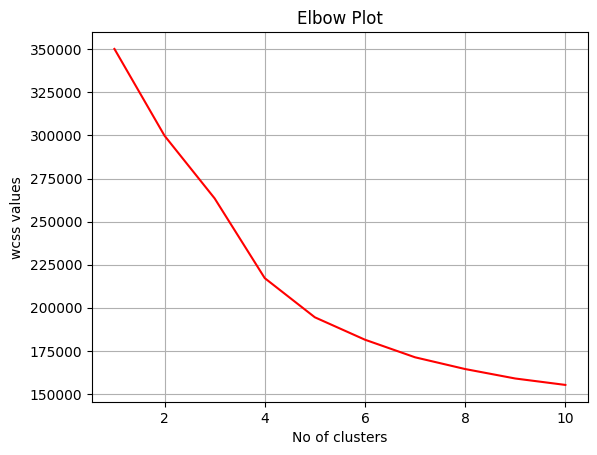

In [74]:
##elbow plt(k vs wcss)

plt.plot(range(1,11),wcss, c='r')
plt.title('Elbow Plot')
plt.xlabel('No of clusters')
plt.ylabel('wcss values')
plt.grid()
plt.show()

In [75]:
##Optimum no of clusters=6
## Inference from the elbow plot

## now create a k means model with 6 clusters

##Initialize model
k_mean= KMeans(n_clusters=6, n_init=5)

##Model building
k_mean.fit(X)

##Model prediction
cluster_label=k_mean.predict(X)
cluster_label

array([2, 1, 3, ..., 1, 2, 1], dtype=int32)

In [76]:
##Before adding cluster column in the df


policy_df.head()

,age,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_Professional,occupation_Service,occupation_White-Collar,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,0.035123,1.171344,1,1,2.844037,-0.221302,-0.032550,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
1,0.864064,1.171344,0,1,-0.297971,-0.221302,-2.269214,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1
2,-0.040236,-0.456772,1,1,-0.297971,-0.221302,-0.032550,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
3,1.090139,-1.270830,0,1,-0.297971,-0.221302,-0.032550,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,-0.793819,1.171344,0,0,-0.297971,-0.221302,-0.032550,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0


In [77]:
##Updating the df with the cluster infomation

policy_df['Cluster']= cluster_label

In [78]:
policy_df.head()

,age,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_Professional,occupation_Service,occupation_White-Collar,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,Cluster
0,0.035123,1.171344,1,1,2.844037,-0.221302,-0.032550,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,2
1,0.864064,1.171344,0,1,-0.297971,-0.221302,-2.269214,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
2,-0.040236,-0.456772,1,1,-0.297971,-0.221302,-0.032550,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,3
3,1.090139,-1.270830,0,1,-0.297971,-0.221302,-0.032550,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,4
4,-0.793819,1.171344,0,0,-0.297971,-0.221302,-0.032550,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1


In [79]:
## Cheking how many values in each cluster

policy_df['Cluster'].value_counts()

,count
Cluster,
3,14855
1,10087
0,9671
4,7952
2,3970
5,2281


## Evaluating Cluster Quality

In [80]:
#  Silhouette Score (Sampling for performance if dataset is large)
sample_size = 10000
score = silhouette_score(X.drop('Cluster', axis=1, errors='ignore'),cluster_label, sample_size=sample_size, random_state=42)
print(f"Silhouette Score (sampled {sample_size}): {score:.4f}")

Silhouette Score (sampled 10000): 0.1636


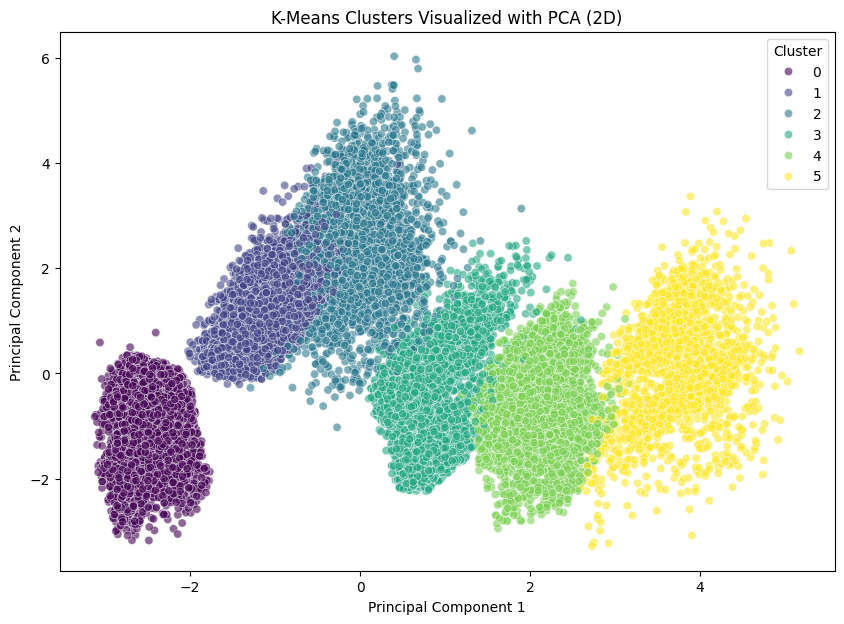

In [81]:
# PCA Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=cluster_label, palette='viridis', alpha=0.6)
plt.title('K-Means Clusters Visualized with PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()